# NFL Draft Model
## Feature Engineering

This notebook builds the feature set for the draft prediction model. We take the raw college stats and combine measurables and engineer meaningful predictive features — normalizing stats by position, creating efficiency metrics, handling missing values, and building the final feature matrix that will feed into the XGBoost model.

---

### Setup & Data Load

In [1]:
%pip install matplotlib seaborn pandas==2.2.2 scikit-learn --prefer-binary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 18.6 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 30.0 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


---

### Imports & Data Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
processed_path = os.path.join(project_root, "data", "processed")
figures_path = os.path.join(project_root, "outputs", "figures")

df = pd.read_parquet(os.path.join(processed_path, "final_dataset.parquet"), engine='pyarrow')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {len(df.columns)}")

Dataset shape: (2826, 113)
Columns: 113


Dataset loaded. Now we engineer features in four steps:
1. Define position groups
2. Select and normalize college stats by position
3. Add combine measurables
4. Handle missing values and build final feature matrix

---

### Step 1 — Define Position Groups and Features

In [3]:
# Define position groups
position_map = {
    'QB': 'QB',
    'RB': 'RB', 'FB': 'RB',
    'WR': 'WR',
    'TE': 'TE',
    'T': 'OL', 'G': 'OL', 'C': 'OL', 'OL': 'OL', 'OT': 'OL', 'OG': 'OL',
    'DE': 'EDGE', 'OLB': 'EDGE',
    'DT': 'DT', 'NT': 'DT',
    'LB': 'LB', 'ILB': 'LB', 'MLB': 'LB',
    'CB': 'DB', 'S': 'DB', 'DB': 'DB', 'FS': 'DB', 'SS': 'DB'
}

df['position_group'] = df['position_draft'].map(position_map)

print("Position group distribution:")
print(df['position_group'].value_counts())
print(f"\nUnmapped positions:")
print(df[df['position_group'].isna()]['position_draft'].value_counts())

Position group distribution:
position_group
DB      585
OL      451
WR      355
EDGE    319
LB      294
RB      249
DT      225
TE      159
QB      115
Name: count, dtype: int64

Unmapped positions:
position_draft
DL    27
K     21
P     20
LS     6
Name: count, dtype: int64


Position groups defined successfully. 9 main position groups covering 2,753 players. The 74 unmapped players are specialists (K, P, LS) and generic DL designations — we'll exclude specialists from the model and map DL to DT.

---

### Step 2 — Map Remaining Positions and Select Features by Position

In [4]:
# Map remaining positions
df['position_group'] = df['position_group'].fillna(
    df['position_draft'].map({'DL': 'DT', 'K': 'K', 'P': 'P', 'LS': 'LS'})
)

# Exclude specialists from modeling
df_model = df[~df['position_group'].isin(['K', 'P', 'LS'])].copy()
print(f"Model dataset: {len(df_model):,} players")

# Convert height to inches
def height_to_inches(ht):
    if pd.isna(ht):
        return np.nan
    try:
        parts = str(ht).split('-')
        return int(parts[0]) * 12 + int(parts[1])
    except:
        return np.nan

df_model['ht_inches'] = df_model['ht'].apply(height_to_inches)

# Define features by position group
position_features = {
    'QB': ['passing_YDS', 'passing_TD', 'passing_PCT', 'passing_YPA', 'passing_INT'],
    'RB': ['rushing_YDS', 'rushing_TD', 'rushing_YPC', 'rushing_CAR', 
           'receiving_REC', 'receiving_YDS'],
    'WR': ['receiving_YDS', 'receiving_REC', 'receiving_TD', 'receiving_YPR'],
    'TE': ['receiving_YDS', 'receiving_REC', 'receiving_TD'],
    'OL': [],  # No college stats available
    'EDGE': ['defensive_SACKS', 'defensive_TFL', 'defensive_TOT', 'defensive_SOLO'],
    'DT': ['defensive_TFL', 'defensive_TOT', 'defensive_SOLO'],
    'LB': ['defensive_TOT', 'defensive_SOLO', 'defensive_TFL', 'interceptions_INT'],
    'DB': ['defensive_SOLO', 'defensive_PD', 'interceptions_INT', 'defensive_TOT']
}

# Universal features for all positions
universal_features = ['round', 'pick', 'age', 'ht_inches', 'wt', 
                      'forty', 'bench', 'vertical', 'broad_jump']

print("\nFeature counts by position:")
for pos, feats in position_features.items():
    print(f"  {pos}: {len(feats)} college stats + {len(universal_features)} universal = {len(feats) + len(universal_features)} total")

Model dataset: 2,779 players

Feature counts by position:
  QB: 5 college stats + 9 universal = 14 total
  RB: 6 college stats + 9 universal = 15 total
  WR: 4 college stats + 9 universal = 13 total
  TE: 3 college stats + 9 universal = 12 total
  OL: 0 college stats + 9 universal = 9 total
  EDGE: 4 college stats + 9 universal = 13 total
  DT: 3 college stats + 9 universal = 12 total
  LB: 4 college stats + 9 universal = 13 total
  DB: 4 college stats + 9 universal = 13 total


2,779 players in the model dataset after excluding specialists. Feature counts are reasonable across all position groups — OL relies entirely on combine and draft slot data since no individual college stats are tracked.

---

### Step 3 — Normalize College Stats Within Position Group
Raw counting stats are biased by playing time and usage. We normalize each stat to a per-game basis and then z-score within position group so players are compared only against peers at their position.

In [5]:
# Normalize stats per game where applicable
counting_stats = [
    'passing_YDS', 'passing_TD', 'passing_INT',
    'rushing_YDS', 'rushing_TD', 'rushing_CAR',
    'receiving_YDS', 'receiving_REC', 'receiving_TD',
    'defensive_SACKS', 'defensive_TFL', 'defensive_TOT', 'defensive_SOLO',
    'defensive_PD', 'interceptions_INT'
]

# We don't have games played from college stats so we'll use z-scores within position
# Z-score each stat within position group
def zscore_within_group(df, col, group_col):
    result = df.copy()
    for group in df[group_col].unique():
        mask = df[group_col] == group
        vals = df.loc[mask, col]
        mean = vals.mean()
        std = vals.std()
        if std > 0:
            result.loc[mask, f'{col}_z'] = (vals - mean) / std
        else:
            result.loc[mask, f'{col}_z'] = 0
    return result

# Apply z-scoring for all college stats
all_college_stats = list(set(
    stat for stats in position_features.values() for stat in stats
))

for stat in all_college_stats:
    if stat in df_model.columns:
        df_model = zscore_within_group(df_model, stat, 'position_group')

z_cols = [f'{s}_z' for s in all_college_stats if f'{s}_z' in df_model.columns]
print(f"Z-scored columns created: {len(z_cols)}")
print(z_cols)

Z-scored columns created: 19
['passing_YDS_z', 'receiving_TD_z', 'defensive_PD_z', 'receiving_YDS_z', 'rushing_CAR_z', 'rushing_YPC_z', 'receiving_REC_z', 'rushing_TD_z', 'defensive_TFL_z', 'rushing_YDS_z', 'defensive_SOLO_z', 'passing_INT_z', 'passing_YPA_z', 'defensive_TOT_z', 'receiving_YPR_z', 'passing_PCT_z', 'interceptions_INT_z', 'passing_TD_z', 'defensive_SACKS_z']


19 z-scored college stat columns created. Each stat is now normalized within position group — a QB with a passing_YDS_z of 1.5 produced 1.5 standard deviations more passing yards than the average QB in our dataset, regardless of era or conference.

---

### Step 4 — Build Final Feature Matrix
Assemble the complete feature matrix for each position group, handle missing values, and save.

In [6]:
# Build final feature matrix
feature_dfs = []

for pos_group, college_feats in position_features.items():
    pos_df = df_model[df_model['position_group'] == pos_group].copy()
    
    # Z-scored college stat columns for this position
    z_feats = [f'{f}_z' for f in college_feats if f'{f}_z' in pos_df.columns]
    
    # All features for this position
    all_feats = universal_features + z_feats
    
    # Select relevant columns
    keep_cols = ['pfr_player_id', 'pfr_player_name', 'season_draft', 'position_draft', 
                 'position_group', 'college', 'w_av', 'success'] + all_feats
    keep_cols = [c for c in keep_cols if c in pos_df.columns]
    
    pos_feat_df = pos_df[keep_cols].copy()
    pos_feat_df['feature_set'] = pos_group
    
    feature_dfs.append(pos_feat_df)
    print(f"{pos_group}: {len(pos_feat_df)} players, {len(all_feats)} features")

feature_df = pd.concat(feature_dfs, ignore_index=True)
print(f"\nFull feature dataset: {feature_df.shape}")
print(f"\nMissing value rates:")
print(feature_df[universal_features].isna().mean().round(3))

QB: 115 players, 14 features
RB: 249 players, 15 features
WR: 355 players, 13 features
TE: 159 players, 12 features
OL: 451 players, 9 features
EDGE: 319 players, 13 features
DT: 252 players, 12 features
LB: 294 players, 13 features
DB: 585 players, 13 features

Full feature dataset: (2779, 37)

Missing value rates:
round         0.000
pick          0.000
age           0.000
ht_inches     0.141
wt            0.141
forty         0.200
bench         0.343
vertical      0.286
broad_jump    0.298
dtype: float64


Feature matrix built across all 9 position groups — 2,779 players with up to 37 columns. Missing value rates for combine measurables range from 14% (height/weight) to 34% (bench press). We'll handle these with median imputation within position group.

---

### Step 5 — Handle Missing Values

In [7]:
# Impute missing values with position group median
def impute_within_group(df, cols, group_col):
    result = df.copy()
    for col in cols:
        if col in result.columns:
            for group in result[group_col].unique():
                mask = result[group_col] == group
                median_val = result.loc[mask, col].median()
                result.loc[mask & result[col].isna(), col] = median_val
    return result

# Impute combine measurables
combine_measurables = ['ht_inches', 'wt', 'forty', 'bench', 'vertical', 'broad_jump']
feature_df = impute_within_group(feature_df, combine_measurables, 'position_group')

# Impute z-scored college stats with 0 (league average for position)
z_stat_cols = [c for c in feature_df.columns if c.endswith('_z')]
feature_df[z_stat_cols] = feature_df[z_stat_cols].fillna(0)

# Verify no missing values remain in feature columns
all_feature_cols = universal_features + z_stat_cols
print("Missing values after imputation:")
print(feature_df[all_feature_cols].isna().sum())
print(f"\nFinal feature dataset shape: {feature_df.shape}")
print(f"\nFeature columns: {all_feature_cols}")

# Save
feature_df.to_parquet(os.path.join(processed_path, "feature_matrix.parquet"), 
                      engine='pyarrow', index=False)
print(f"\nSaved to data/processed/feature_matrix.parquet")

Missing values after imputation:
round                  0
pick                   0
age                    0
ht_inches              0
wt                     0
forty                  0
bench                  0
vertical               0
broad_jump             0
passing_YDS_z          0
passing_TD_z           0
passing_PCT_z          0
passing_YPA_z          0
passing_INT_z          0
rushing_YDS_z          0
rushing_TD_z           0
rushing_YPC_z          0
rushing_CAR_z          0
receiving_REC_z        0
receiving_YDS_z        0
receiving_TD_z         0
receiving_YPR_z        0
defensive_SACKS_z      0
defensive_TFL_z        0
defensive_TOT_z        0
defensive_SOLO_z       0
interceptions_INT_z    0
defensive_PD_z         0
dtype: int64

Final feature dataset shape: (2779, 37)

Feature columns: ['round', 'pick', 'age', 'ht_inches', 'wt', 'forty', 'bench', 'vertical', 'broad_jump', 'passing_YDS_z', 'passing_TD_z', 'passing_PCT_z', 'passing_YPA_z', 'passing_INT_z', 'rushing_YDS_z', 'rushi

Zero missing values after imputation. Missing combine measurables were filled with position group medians — a player with no 40 time recorded gets the median 40 time for their position. Missing college stats were filled with 0 — representing exactly average production for their position group, which is the most conservative assumption.

---

### Step 6 — Visualize Feature Distributions
Confirm the engineered features look reasonable before modeling.

/tmp/ipykernel_19802/965033746.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0][2].boxplot(
/tmp/ipykernel_19802/965033746.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1][0].boxplot(
/tmp/ipykernel_19802/965033746.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1][1].boxplot(


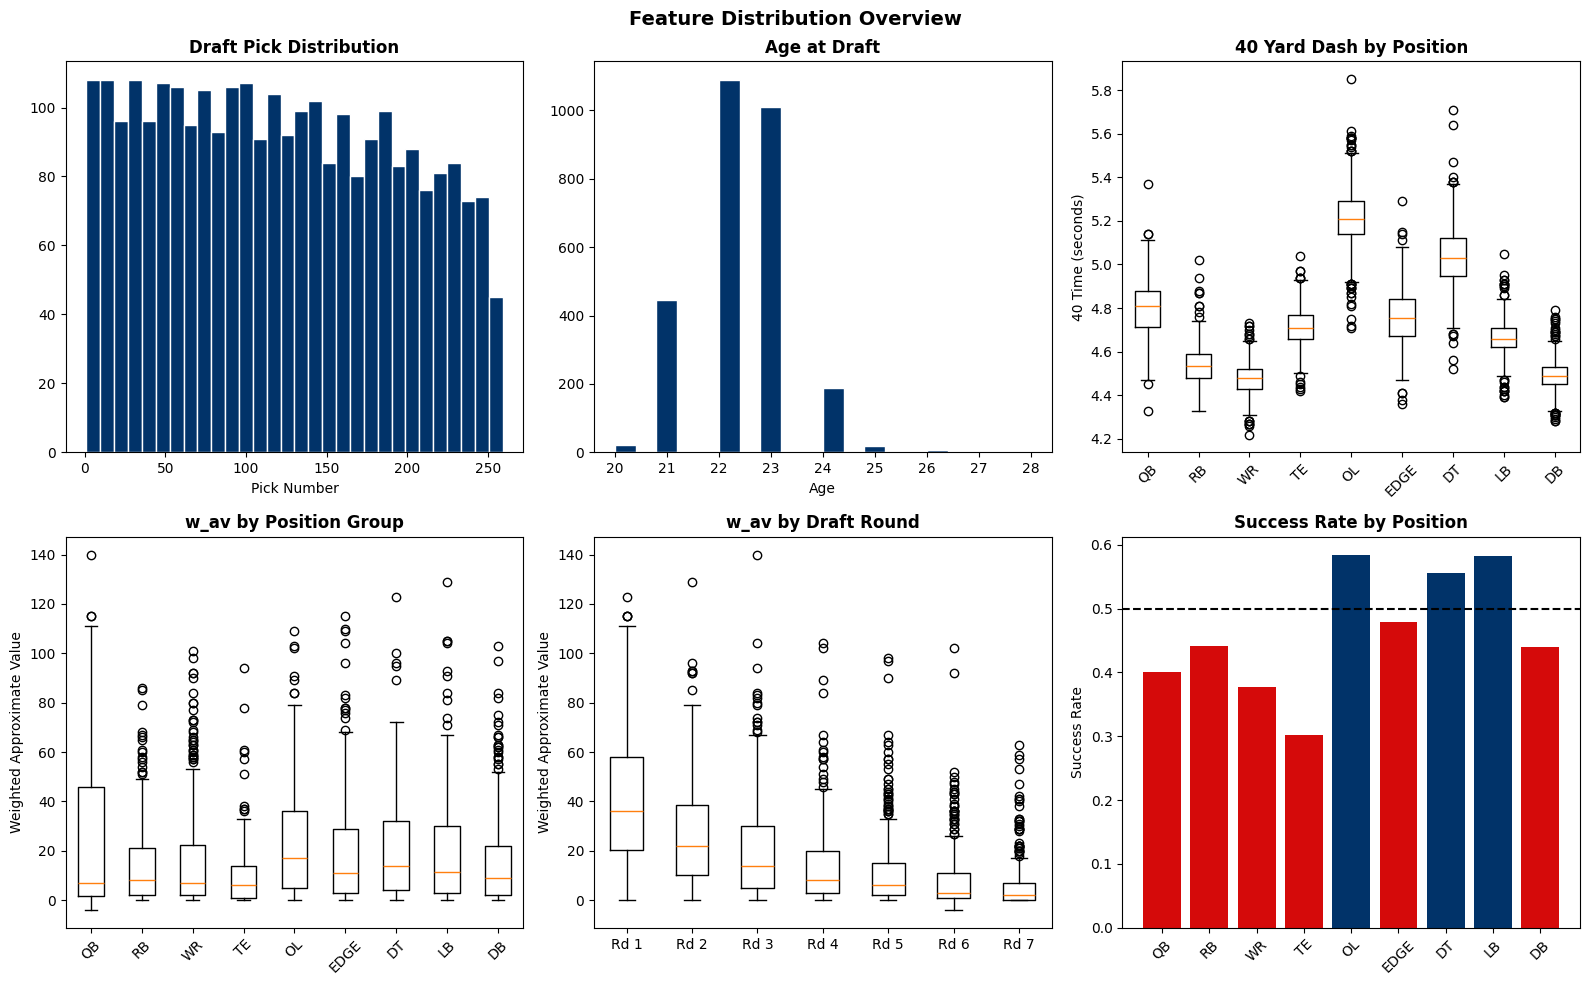

In [8]:
# Visualize key feature distributions by position group
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Pick number distribution
axes[0][0].hist(feature_df['pick'], bins=30, color='#013369', edgecolor='white')
axes[0][0].set_title('Draft Pick Distribution', fontweight='bold')
axes[0][0].set_xlabel('Pick Number')

# Age distribution
axes[0][1].hist(feature_df['age'].dropna(), bins=20, color='#013369', edgecolor='white')
axes[0][1].set_title('Age at Draft', fontweight='bold')
axes[0][1].set_xlabel('Age')

# 40 time by position
position_order = ['QB', 'RB', 'WR', 'TE', 'OL', 'EDGE', 'DT', 'LB', 'DB']
forty_data = feature_df[feature_df['position_group'].isin(position_order)]
axes[0][2].boxplot(
    [forty_data[forty_data['position_group'] == p]['forty'].values 
     for p in position_order],
    labels=position_order
)
axes[0][2].set_title('40 Yard Dash by Position', fontweight='bold')
axes[0][2].set_ylabel('40 Time (seconds)')
axes[0][2].tick_params(axis='x', rotation=45)

# w_av by position
axes[1][0].boxplot(
    [feature_df[feature_df['position_group'] == p]['w_av'].values 
     for p in position_order],
    labels=position_order
)
axes[1][0].set_title('w_av by Position Group', fontweight='bold')
axes[1][0].set_ylabel('Weighted Approximate Value')
axes[1][0].tick_params(axis='x', rotation=45)

# w_av by round
axes[1][1].boxplot(
    [feature_df[feature_df['round'] == r]['w_av'].values 
     for r in range(1, 8)],
    labels=[f'Rd {r}' for r in range(1, 8)]
)
axes[1][1].set_title('w_av by Draft Round', fontweight='bold')
axes[1][1].set_ylabel('Weighted Approximate Value')

# Success rate by position
success_by_pos = feature_df.groupby('position_group')['success'].mean().reindex(position_order)
colors = ['#013369' if x >= 0.5 else '#D50A0A' for x in success_by_pos.values]
axes[1][2].bar(success_by_pos.index, success_by_pos.values, color=colors)
axes[1][2].axhline(y=0.5, color='black', linestyle='--', linewidth=1.5)
axes[1][2].set_title('Success Rate by Position', fontweight='bold')
axes[1][2].set_ylabel('Success Rate')
axes[1][2].tick_params(axis='x', rotation=45)

plt.suptitle('Feature Distribution Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "feature_distributions.png"), dpi=150, bbox_inches='tight')
plt.show()

![Feature Distributions](../outputs/figures/feature_distributions.png)

The feature distributions confirm the dataset is clean and reasonable:

**Draft pick distribution** — fairly uniform across pick numbers with slight dropoff at the end, reflecting normal 7-round draft structure.

**Age at draft** — tightly concentrated at 22-23 years old, with very few players drafted before 21 or after 25. Age will be a useful feature since younger draftees at the same pick tend to have more upside.

**40 yard dash by position** — clear positional separation: DBs and WRs run the fastest (4.4-4.5 range), QBs and TEs in the middle, OL slowest (5.0-5.3). This confirms the combine data is clean.

**w_av by position** — OL and LB show the highest medians reflecting positional longevity. QB shows the widest variance — the highest highs and many busts. WR has the most outliers.

**w_av by round** — clear decline from Round 1 to Round 7 as expected, with significant overlap between adjacent rounds confirming that draft position is imperfect.

**Success rate by position** — OL (58%) and LB (57%) have the highest success rates while WR (30%) and TE (30%) are the hardest to evaluate. This has significant implications for the model — some positions are inherently more predictable than others.

---

### Summary
Feature engineering complete. The final feature matrix contains:
- **2,779 players** across 9 position groups
- **28 features** per player — 9 universal + up to 19 position-specific z-scored college stats
- **Zero missing values** after imputation
- **Two target variables** — `w_av` (continuous) and `success` (binary)